In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re


In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [3]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [4]:
lista_label = df['label'].unique().tolist()

In [5]:
len(lista_label)

54

In [6]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()
df_result['split_type'] = 'unknown'

In [7]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,unknown
1,90245,light-oauth2-data-1719592986.tar,correct,unknown
2,90246,light-oauth2-data-1719592986.tar,correct,unknown
3,90247,light-oauth2-data-1719592986.tar,correct,unknown
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,unknown
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,unknown
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,unknown
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,unknown
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,unknown


In [9]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

# <span style="color:#2ca02c">1. Separamos conjuntos de train, val y test</span>

<span style="color:#2ca02c">Por cada label dividimos los datos en train, val y test</span>


In [10]:
dic_idx_train = {}
dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [11]:
for label in lista_label:
    indices = df[ df['label']== label ].index.values
    idx_train, idx_resto = train_test_split(indices   , test_size=0.4 , random_state=SEED)
    idx_val,   idx_test  = train_test_split(idx_resto , test_size=0.5 , random_state=SEED)
    df_result.loc[idx_train , 'split_type'] = 'train'
    df_result.loc[idx_val   , 'split_type'] = 'val'
    df_result.loc[idx_test  , 'split_type'] = 'test'
    dic_idx_train[label] = idx_train
    dic_idx_resto[label] = idx_resto
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

df_reparto = pd.DataFrame({
    'Cantidad': df_result['split_type'].value_counts(),
    'Porcentaje (%)': (df_result['split_type'].value_counts(normalize=True) * 100).round(2)
})

print("Reparto porcentual de los datos:")
display(df_reparto)

Reparto porcentual de los datos:


,Cantidad,Porcentaje (%)
split_type,,
train,54093,59.98
test,18058,20.02
val,18039,20.00


In [12]:
df_result

,vector_id,execution_name,label,split_type
0,90244,light-oauth2-data-1719592986.tar,correct,test
1,90245,light-oauth2-data-1719592986.tar,correct,train
2,90246,light-oauth2-data-1719592986.tar,correct,train
3,90247,light-oauth2-data-1719592986.tar,correct,test
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [13]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

# <span style="color:#2ca02c">2. Usamos Isolation Forest (IF) para </span>

<span style="color:#2ca02c"> Entrenamos IF con los datos del split 'train' y label 'correct'   </span>


In [14]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [15]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [16]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]

In [17]:
len(idx_correct_train)

10231

In [18]:
idx_correct_val

array([65461, 62557, 89796, ..., 31467, 42793, 37650], shape=(3410,))

In [19]:
idx_correct_test

array([54453, 70322, 76171, ...,  5440, 50166, 71891], shape=(3411,))

In [20]:
X_matrix.shape

(90190, 354)

In [21]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [22]:
idx_correct_test.shape

(3411,)

In [23]:
 df.loc[idx_correct_test].shape

(3411, 5)

In [24]:
df.shape

(90190, 5)

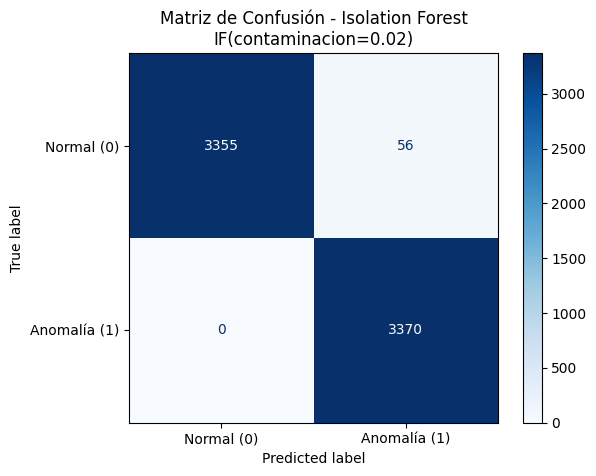

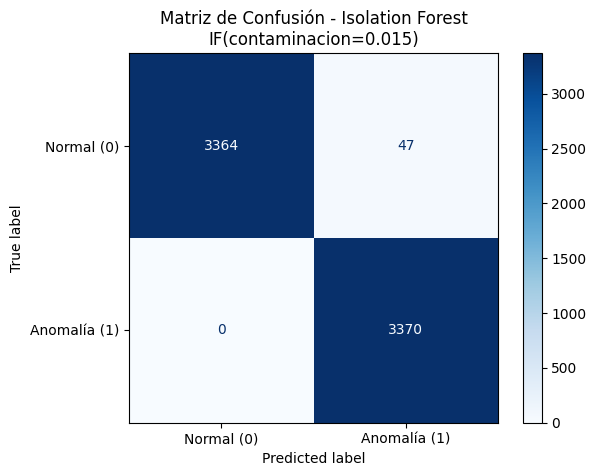

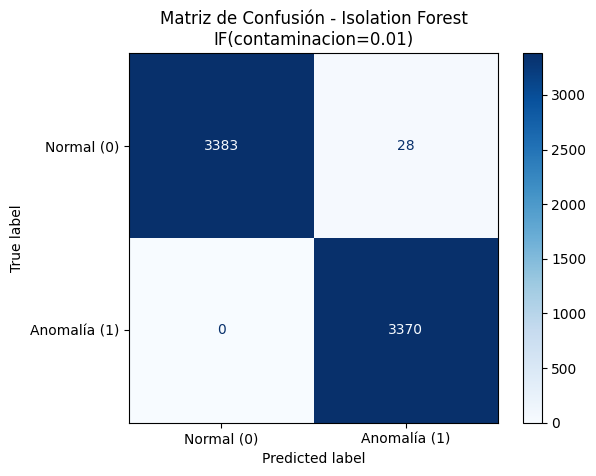

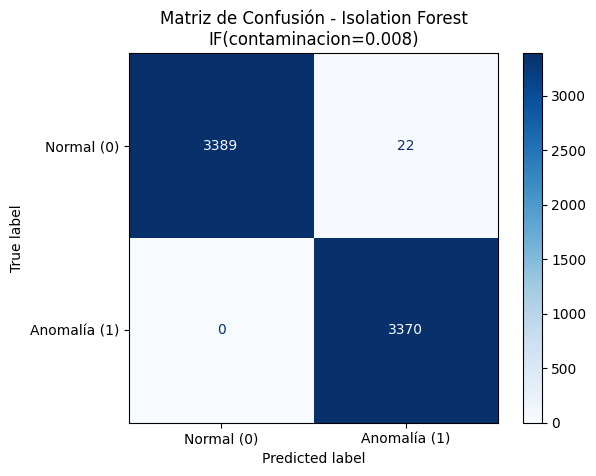

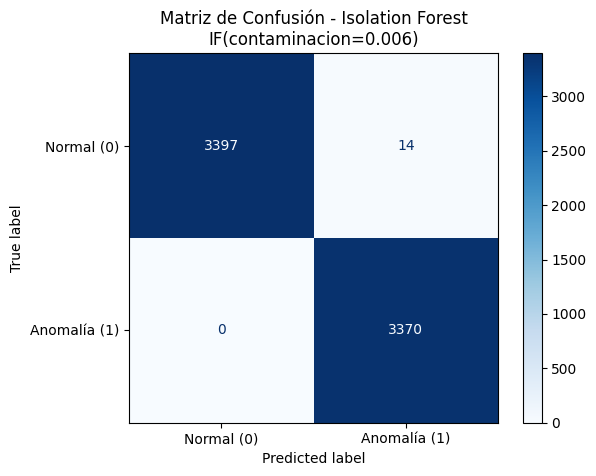

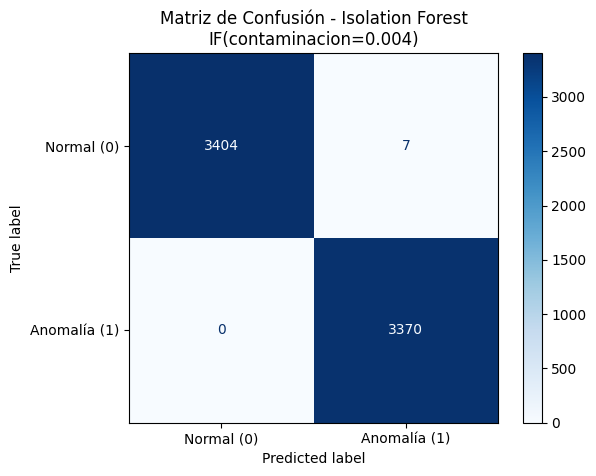

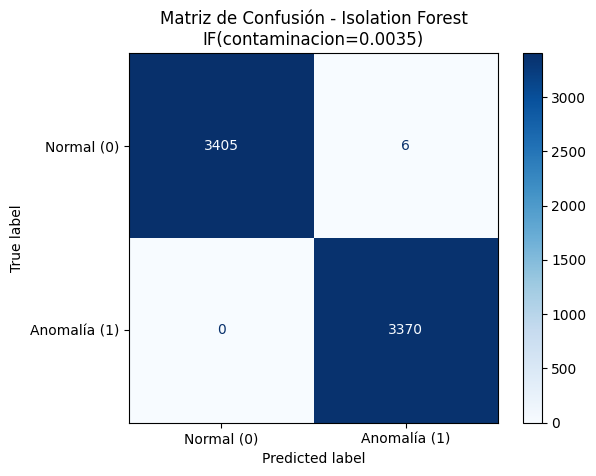

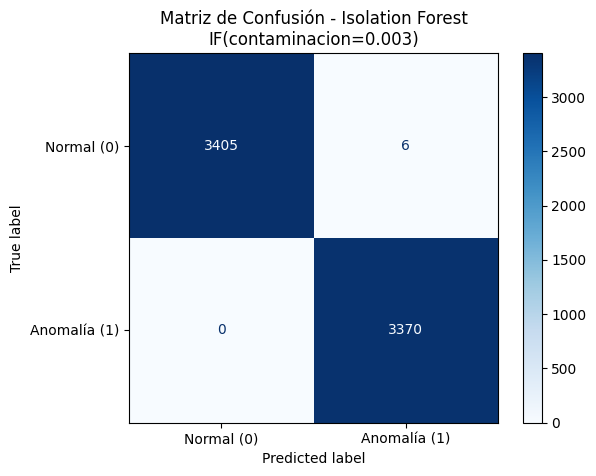

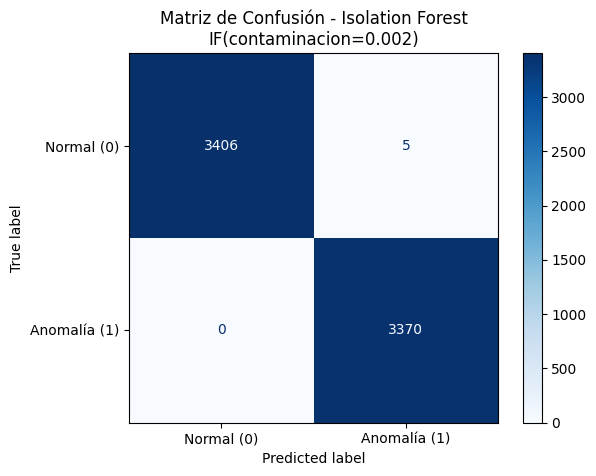

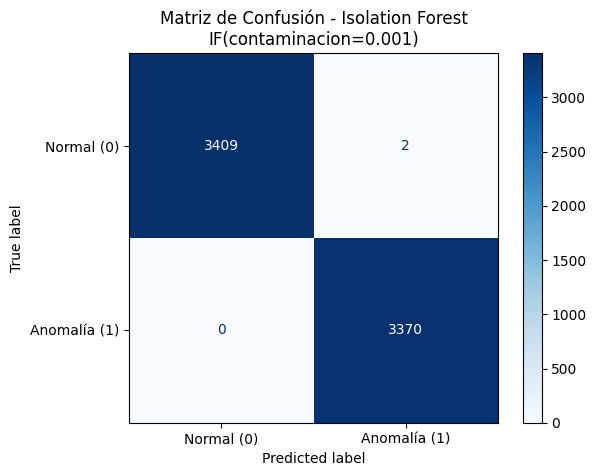

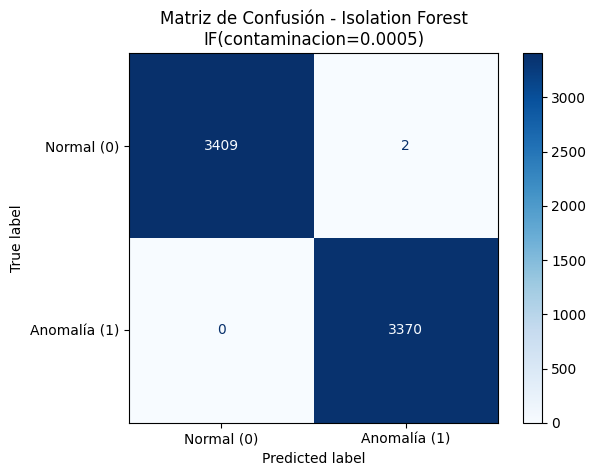

In [25]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

N = 0
lista_result=[]
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion, 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF(contaminacion={contaminacion})'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    

    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: Anomalía (-1) pasa a ser la clase positiva (1) para las métricas, 
    # y lo normal ('correct' / 1) pasa a ser la negativa (0 o -1 dependiendo del enfoque).
    # Usaremos 1 para Anomalía (Positivo) y 0 para Normal (Negativo) para facilitar scikit-learn.
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    
    # 1. Componentes de la matriz de confusión (con anomalía = positivo = 1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)         # Sensibilidad / True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0          # True Negative Rate
    f1 = f1_score(y_true, y_pred, zero_division=0)

    parametros={'contaminacion':contaminacion}
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {

        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualizarla (Opcional: puedes comentar el show si son muchas iteraciones)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - Isolation Forest\n{model_name}')
    plt.show()

# Convertir la lista de registros en un DataFrame global para revisarlos cómodamente
df_anomaly_detection_summary = pd.DataFrame(lista_result)

In [26]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_IF_summary.parquet', index=False,engine='fastparquet')

In [27]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,IF(contaminacion=0.02),"{""contaminacion"": 0.02}",3370,56,3355,0,0.991742,0.983654,1.0,0.983583,0.991760
1,IF(contaminacion=0.015),"{""contaminacion"": 0.015}",3370,47,3364,0,0.993069,0.986245,1.0,0.986221,0.993075
2,IF(contaminacion=0.01),"{""contaminacion"": 0.01}",3370,28,3383,0,0.995871,0.991760,1.0,0.991791,0.995863
3,IF(contaminacion=0.008),"{""contaminacion"": 0.008}",3370,22,3389,0,0.996756,0.993514,1.0,0.993550,0.996747
4,IF(contaminacion=0.006),"{""contaminacion"": 0.006}",3370,14,3397,0,0.997935,0.995863,1.0,0.995896,0.997927
5,IF(contaminacion=0.004),"{""contaminacion"": 0.004}",3370,7,3404,0,0.998968,0.997927,1.0,0.997948,0.998963
6,IF(contaminacion=0.0035),"{""contaminacion"": 0.0035}",3370,6,3405,0,0.999115,0.998223,1.0,0.998241,0.999111
7,IF(contaminacion=0.003),"{""contaminacion"": 0.003}",3370,6,3405,0,0.999115,0.998223,1.0,0.998241,0.999111
8,IF(contaminacion=0.002),"{""contaminacion"": 0.002}",3370,5,3406,0,0.999263,0.998519,1.0,0.998534,0.999259
9,IF(contaminacion=0.001),"{""contaminacion"": 0.001}",3370,2,3409,0,0.999705,0.999407,1.0,0.999414,0.999703


In [28]:
model = joblib.load(f'{FOLDER_SALIDA}/models/IF(contaminacion=0.0005).joblib')

Y_test = df_result.loc[idx_test, 'label'].apply(lambda x: 1 if x == 'correct' else -1)

result = permutation_importance(
    model, X_test, Y_test, 
    scoring='f1',
    n_repeats=10, 
    random_state=SEED, 
    n_jobs=-1
)

# Creamos el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': lista_metric_name_vector,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

                                        Caracteristica  Importancia
353                     scrape_series_added_mod(lag_2)          0.0
334       prometheus_tsdb_head_active_appenders(lag_2)          0.0
333  prometheus_target_interval_length_seconds_sum_...          0.0
332  prometheus_target_interval_length_seconds_coun...          0.0
331   prometheus_target_interval_length_seconds(lag_2)          0.0
329  prometheus_remote_storage_highest_timestamp_in...          0.0
328  prometheus_http_response_size_bytes_sum_diff(l...          0.0
327  prometheus_http_response_size_bytes_count_diff...          0.0
326  prometheus_http_response_size_bytes_bucket_dif...          0.0
325  prometheus_http_request_duration_seconds_sum_d...          0.0


In [29]:
df_importancia.shape

(354, 2)

In [30]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)
print(df_importancia[df_importancia['Importancia']<0].shape)
lista_features_poco_importantes=df_importancia[df_importancia['Importancia']<0]['Caracteristica'].tolist()
lista_features_poco_importantes = [re.sub(r'\s*\(.*?\)', '', cadena) for cadena in lista_features_poco_importantes]
lista_features_poco_importantes = list(set(lista_features_poco_importantes))
print(len(lista_features_poco_importantes))

,Caracteristica,Importancia
353,scrape_series_added_mod(lag_2),0.000000
334,prometheus_tsdb_head_active_appenders(lag_2),0.000000
333,prometheus_target_interval_length_seconds_sum_...,0.000000
332,prometheus_target_interval_length_seconds_coun...,0.000000
331,prometheus_target_interval_length_seconds(lag_2),0.000000
329,prometheus_remote_storage_highest_timestamp_in...,0.000000
328,prometheus_http_response_size_bytes_sum_diff(l...,0.000000
327,prometheus_http_response_size_bytes_count_diff...,0.000000
326,prometheus_http_response_size_bytes_bucket_dif...,0.000000
325,prometheus_http_request_duration_seconds_sum_d...,0.000000


(61, 2)
40


In [31]:
lista_metric_name_vector
lista_metric_name_reducida_IF=[]
lista_idx_reducida_IF=[]
ID=0
for metric_name in lista_metric_name_vector:
    DESCARTAR=False
    for metric_name_poco_importante in lista_features_poco_importantes:
        if metric_name.find(metric_name_poco_importante)>=0:
            DESCARTAR=True
            break
    if not DESCARTAR:
        lista_metric_name_reducida_IF.append(metric_name)
        lista_idx_reducida_IF.append(ID)
    ID+=1
        
        




In [32]:
len(lista_metric_name_reducida_IF)

222

In [33]:
X_matrix_reducida      = X_matrix[:, lista_idx_reducida_IF]
X_correct_train        = X_matrix_reducida[idx_correct_train]
X_test                 = X_matrix_reducida[idx_test]

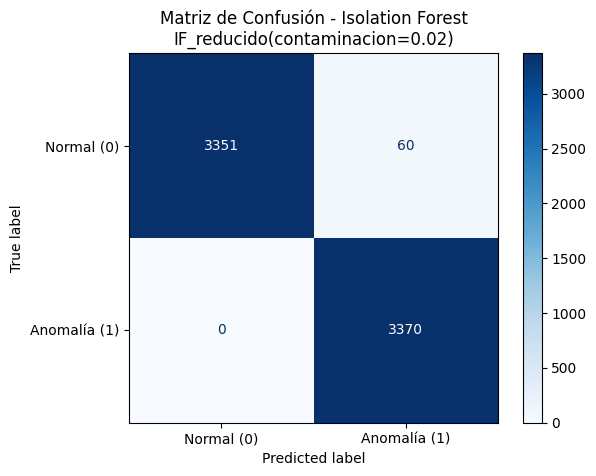

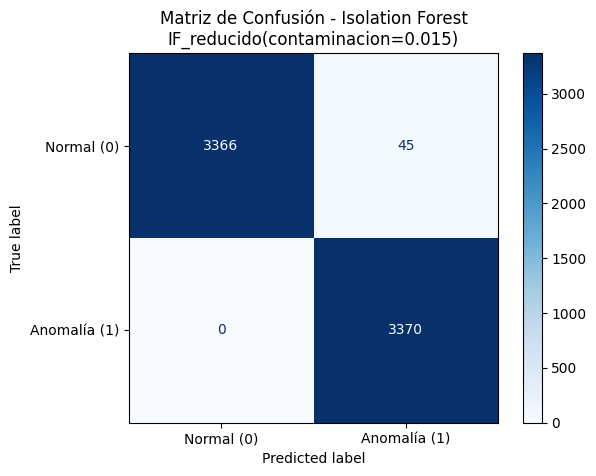

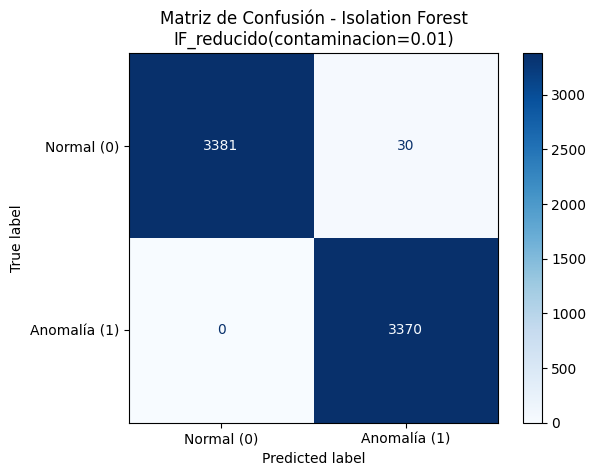

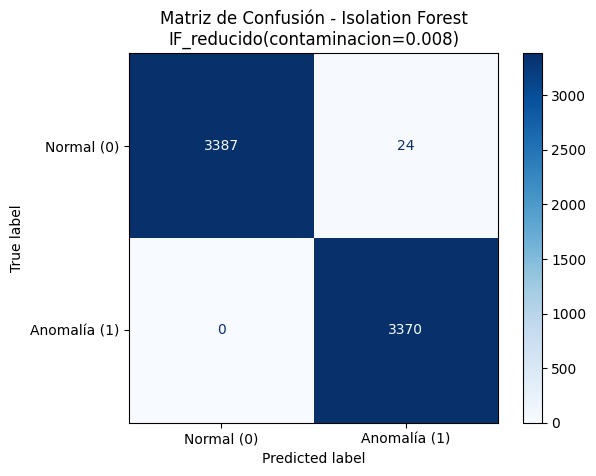

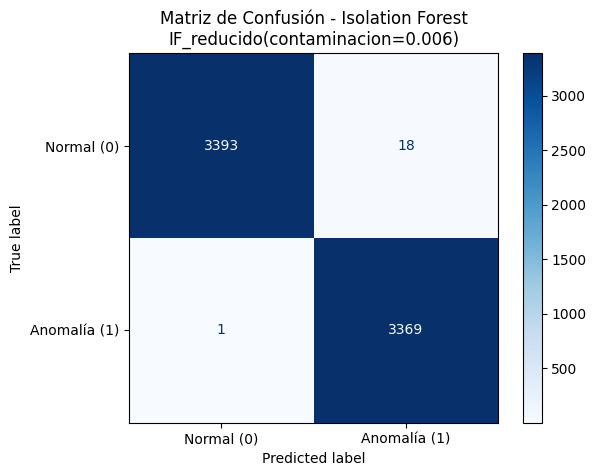

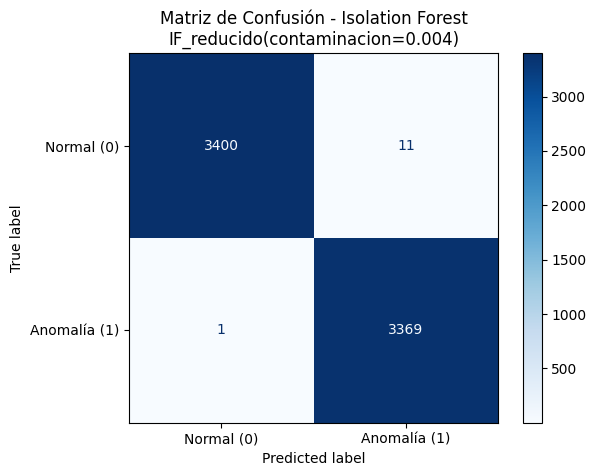

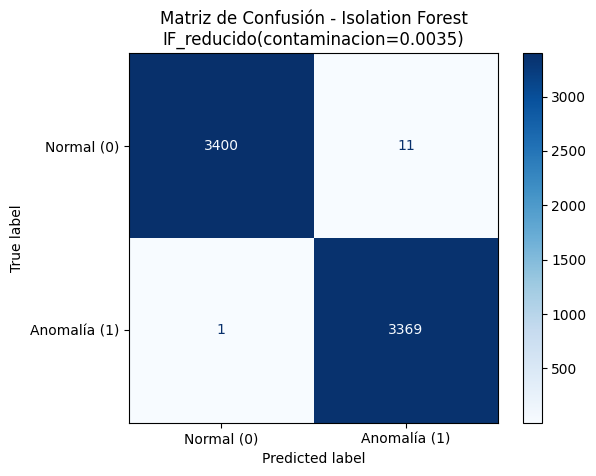

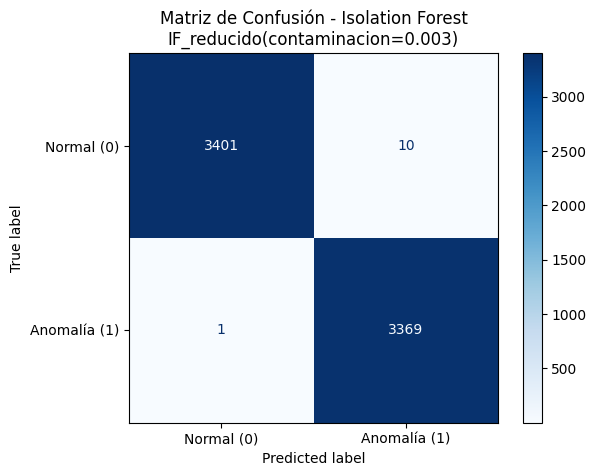

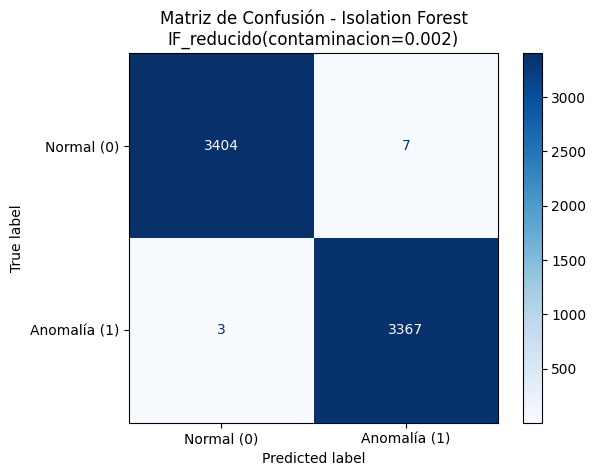

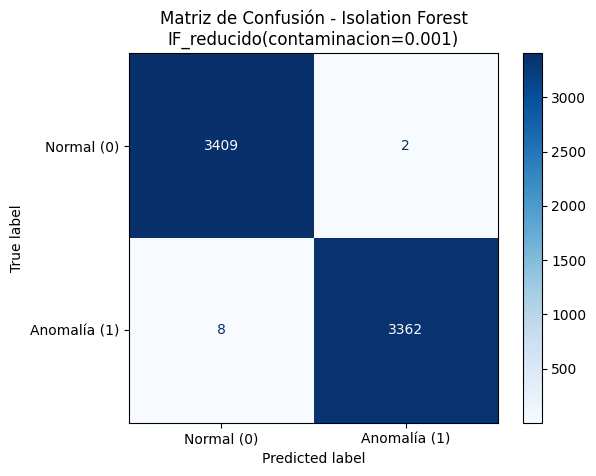

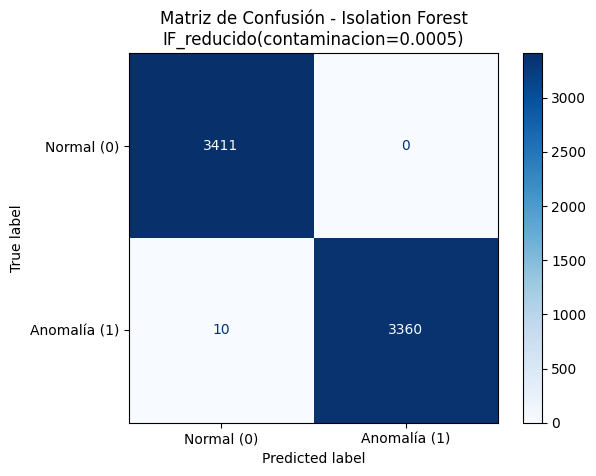

In [34]:
for contaminacion in [0.02, 0.015, 0.01, 0.008, 0.006, 0.004, 0.0035, 0.003, 0.002, 0.001, 0.0005]:
    N += 1
    model = IsolationForest(
        n_estimators=200, 
        max_samples='auto', 
        contamination=contaminacion, 
        random_state=SEED
    )
    model.fit(X_correct_train)
    scores = model.decision_function(X_test)
    Y_pred = model.predict(X_test)

    model_name = f'IF_reducido(contaminacion={contaminacion})'
    joblib.dump(model, f'{FOLDER_SALIDA}/models/{model_name}.joblib')
    

    df_result[f'result_({model_name})'] = float('nan')
    df_result[f'scores_({model_name})'] = float('nan')
    df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
    df_result.loc[idx_test, f'scores_({model_name})'] = scores
    
    # Mapeo: Anomalía (-1) pasa a ser la clase positiva (1) para las métricas, 
    # y lo normal ('correct' / 1) pasa a ser la negativa (0 o -1 dependiendo del enfoque).
    # Usaremos 1 para Anomalía (Positivo) y 0 para Normal (Negativo) para facilitar scikit-learn.
    y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
    y_pred = df_result.loc[idx_test, f'result_({model_name})'].apply(lambda x: 0 if x == 1 else 1)
    
    # 1. Componentes de la matriz de confusión (con anomalía = positivo = 1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Cálculo de métricas
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)         # Sensibilidad / True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0          # True Negative Rate
    f1 = f1_score(y_true, y_pred, zero_division=0)

    parametros={'contaminacion':contaminacion}
    # 3. Guardar en un diccionario de registro
    reg_resultado_algoritmo = {

        'test_name': model_name,
        'parametros': json.dumps(parametros),
        'TP': int(tp),
        'FP': int(fp),
        'TN': int(tn),
        'FN': int(fn),
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1)
    }
    lista_result.append(reg_resultado_algoritmo)
    
    # 4. Visualizarla (Opcional: puedes comentar el show si son muchas iteraciones)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - Isolation Forest\n{model_name}')
    plt.show()

# Convertir la lista de registros en un DataFrame global para revisarlos cómodamente
df_anomaly_detection_summary = pd.DataFrame(lista_result)

In [35]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score
0,IF(contaminacion=0.02),"{""contaminacion"": 0.02}",3370,56,3355,0,0.991742,0.983654,1.000000,0.983583,0.991760
1,IF(contaminacion=0.015),"{""contaminacion"": 0.015}",3370,47,3364,0,0.993069,0.986245,1.000000,0.986221,0.993075
2,IF(contaminacion=0.01),"{""contaminacion"": 0.01}",3370,28,3383,0,0.995871,0.991760,1.000000,0.991791,0.995863
3,IF(contaminacion=0.008),"{""contaminacion"": 0.008}",3370,22,3389,0,0.996756,0.993514,1.000000,0.993550,0.996747
4,IF(contaminacion=0.006),"{""contaminacion"": 0.006}",3370,14,3397,0,0.997935,0.995863,1.000000,0.995896,0.997927
5,IF(contaminacion=0.004),"{""contaminacion"": 0.004}",3370,7,3404,0,0.998968,0.997927,1.000000,0.997948,0.998963
6,IF(contaminacion=0.0035),"{""contaminacion"": 0.0035}",3370,6,3405,0,0.999115,0.998223,1.000000,0.998241,0.999111
7,IF(contaminacion=0.003),"{""contaminacion"": 0.003}",3370,6,3405,0,0.999115,0.998223,1.000000,0.998241,0.999111
8,IF(contaminacion=0.002),"{""contaminacion"": 0.002}",3370,5,3406,0,0.999263,0.998519,1.000000,0.998534,0.999259
9,IF(contaminacion=0.001),"{""contaminacion"": 0.001}",3370,2,3409,0,0.999705,0.999407,1.000000,0.999414,0.999703


In [ ]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_IF_summary.parquet', index=False,engine='fastparquet')